# **`Inatel - C318 (Tópicos Especiais II) - 2026/1`**

# <font color='green'>**Atividade 02: Análise Exploratória de Dados (EDA)**</font>

## <font color='cyan'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte a apostila disponibilizada pelo professor para se familiarizar com os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**Uso consciente de Inteligência Artificial (LLMs):**</font>
  - O uso de assistentes (como Gemini, ChatGPT, Claude) é permitido, mas exige responsabilidade técnica:
    - Em vez de pedir a solução completa, peça para a IA explicar conceitos, sugerir abordagens ou ajudar a depurar erros de código;
    - Você é o responsável por cada linha de código entregue. Não insira no notebook implementações que você não compreende integralmente ou não saberia explicar;
    - Modelos de linguagem podem "alucinar" funções ou sugerir métodos obsoletos de bibliotecas em Python. Sempre teste e verifique a documentação oficial;
    - Quando utilizar a IA para gerar ou refatorar blocos lógicos complexos, indique isso através de comentários no próprio código;
- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='cyan'>ciano</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação (ex: `!pip install nome_da_biblioteca`);
- <font color='red'>**Renomeie o termo `_Enunciado` para `_seu_numero_de_matricula` no nome do arquivo (exemplo: `C318_2026_1_Atividade_02_12345.ipynb`)**</font>;
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

## <font color='green'>Contextualização</font>

### <font color='cyan'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: data de criação, domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.
- #### <font color='cyan'>Becker, B. & Kohavi, R. (1996). Adult Dataset. UCI Machine Learning Repository. https://doi.org/10.24432/C5XW20.</font>

O dataset Adult Dataset, foi criado por Becker e Kohavi em 1996 e disponibilizado no UCI Machine Learning Repository, foi extraído do Censo dos EUA de 1994. Seu objetivo é apoiar estudos de aprendizado de máquina, especialmente para ver se a renda anual de uma pessoa é maior ou menor que US$50.000, utilizando informações demográficas, educacionais e ocupacionais, como idade, escolaridade, ocupação, estado civil, sexo e horas trabalhadas por semana.

## <font color='green'>Preparação</font>

### <font color='cyan'>Dataset: Becker, B. & Kohavi, R. (1996). Adult Dataset. UCI Machine Learning Repository. https://doi.org/10.24432/C5XW20.</font>

In [1]:
!pip install pandas ucimlrepo


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd

from pprint import pprint
from ucimlrepo import fetch_ucirepo

# fetch dataset
adult = fetch_ucirepo(id=2)

In [3]:
pprint(adult.metadata)

{'abstract': 'Predict whether annual income of an individual exceeds $50K/yr '
             'based on census data. Also known as "Census Income" dataset. ',
 'additional_info': {'citation': None,
                     'funded_by': None,
                     'instances_represent': None,
                     'preprocessing_description': None,
                     'purpose': None,
                     'recommended_data_splits': None,
                     'sensitive_data': None,
                     'summary': 'Extraction was done by Barry Becker from the '
                                '1994 Census database.  A set of reasonably '
                                'clean records was extracted using the '
                                'following conditions: ((AAGE>16) && (AGI>100) '
                                '&& (AFNLWGT>1)&& (HRSWK>0))\n'
                                '\n'
                                'Prediction task is to determine whether a '
                               

In [4]:
adult.variables

,name,role,type,demographic,description,units,missing_values
0,age,Feature,Integer,Age,N/A,None,no
1,workclass,Feature,Categorical,Income,"Private, Self-emp-not-inc, Self-emp-inc, Feder...",None,yes
2,fnlwgt,Feature,Integer,None,None,None,no
3,education,Feature,Categorical,Education Level,"Bachelors, Some-college, 11th, HS-grad, Prof-...",None,no
4,education-num,Feature,Integer,Education Level,None,None,no
5,marital-status,Feature,Categorical,Other,"Married-civ-spouse, Divorced, Never-married, S...",None,no
6,occupation,Feature,Categorical,Other,"Tech-support, Craft-repair, Other-service, Sal...",None,yes
7,relationship,Feature,Categorical,Other,"Wife, Own-child, Husband, Not-in-family, Other...",None,no
8,race,Feature,Categorical,Race,"White, Asian-Pac-Islander, Amer-Indian-Eskimo,...",None,no
9,sex,Feature,Binary,Sex,"Female, Male.",None,no


In [5]:
X = adult.data.features
y = adult.data.targets

df = pd.concat([X, y], axis='columns')

df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K.
48838,64,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40,United-States,<=50K.
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K.
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K.


## <font color='green'>**2.1 Conjuntos de Dados**</font>

### <font color='cyan'>Q1: Exiba 10 amostras aleatórias do conjunto de dados.</font>

In [6]:
df.sample(10)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
21923,40,Private,109969,11th,7,Divorced,Other-service,Other-relative,White,Female,0,0,20,United-States,<=50K
35173,27,NaN,258231,HS-grad,9,Never-married,NaN,Not-in-family,White,Male,0,0,35,NaN,<=50K.
26382,47,Private,431515,Assoc-voc,11,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,>50K
39816,36,Private,234901,Some-college,10,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,40,United-States,<=50K.
3109,18,Private,179203,Some-college,10,Never-married,Sales,Own-child,White,Female,0,0,20,United-States,<=50K
24186,31,Private,201122,Some-college,10,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,>50K
32064,49,Private,93639,Bachelors,13,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,43,United-States,<=50K
29855,61,Local-gov,248595,1st-4th,2,Married-civ-spouse,Other-service,Husband,White,Male,0,0,40,Mexico,<=50K
22810,25,Private,109390,HS-grad,9,Never-married,Transport-moving,Own-child,White,Male,0,0,70,United-States,<=50K
37023,38,Private,312766,Bachelors,13,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,>50K.


### <font color='cyan'>Q2: Quantas amostras o conjunto de dados possui?</font>

In [7]:
df.shape[0]

48842

### <font color='cyan'>Q3: Quantas características o conjunto de dados possui?</font>

In [8]:
X.shape[1]

14

### <font color='cyan'>Q4: O conjunto de dados possui características numéricas? Se sim, escreva seu(s) nome(s) e classifique-a(s) como contínua(s) e/ou discreta(s).</font>
- #### <font color='cyan'>Observação: considere que uma caraterística numérica é discreta se possui menos que 50 valores únicos.</font>

In [9]:
num_cols = df.select_dtypes(include='number')

for col in num_cols.columns:
    unique_vals = df[col].nunique()
    if unique_vals < 50:
        print(col, "- discreta")
    else:
        print(col, "- contínua")

age - contínua
fnlwgt - contínua
education-num - discreta
capital-gain - contínua
capital-loss - contínua
hours-per-week - contínua


### <font color='cyan'>Q5: O conjunto de dados possui características categóricas? Se sim, escreva seu(s) nome(s) e sua(s) quantidade(s) de valores únicos.</font>

In [10]:
cat_cols = df.select_dtypes(include='object')

for col in cat_cols.columns:
    print(col, "-", df[col].nunique(), "valores únicos")

workclass - 9 valores únicos
education - 16 valores únicos
marital-status - 7 valores únicos
occupation - 15 valores únicos
relationship - 6 valores únicos
race - 5 valores únicos
sex - 2 valores únicos
native-country - 42 valores únicos
income - 4 valores únicos


## <font color='green'>**2.2 Estatística Descritiva Básica**</font>

### <font color='cyan'> Q6: Escolha uma característica numérica do conjunto de dados. Escreva seu nome a seguir.</font>

Age

### <font color='cyan'> Q7: Calcule e mostre suas Medidas de Tendência Central (média, mediana e moda).</font>

In [11]:
# média
media = df['age'].mean()

# mediana
mediana = df['age'].median()

# moda
moda = df['age'].mode()[0]

print("Média:", media)
print("Mediana:", mediana)
print("Moda:", moda)

Média: 38.64358543876172
Mediana: 37.0
Moda: 36


### <font color='cyan'> Q8: Calcule e mostre suas Medidas de Dispersão (mínimo, máximo e amplitude).</font>

In [12]:
# mínimo
minimo = df['age'].min()

# máximo
maximo = df['age'].max()

# amplitude
amplitude = maximo - minimo

print("Mínimo:", minimo)
print("Máximo:", maximo)
print("Amplitude:", amplitude)

Mínimo: 17
Máximo: 90
Amplitude: 73


## <font color='green'>**2.3 Análise Univariada**</font>

### <font color='cyan'> Q9: Escolha uma característica categórica do conjunto de dados. Escreva seu nome a seguir.</font>

Education

### <font color='cyan'> Q10: Crie e exiba uma Tabela de Frequência e/ou um Gráfico de Barras para a característica escolhida.</font>

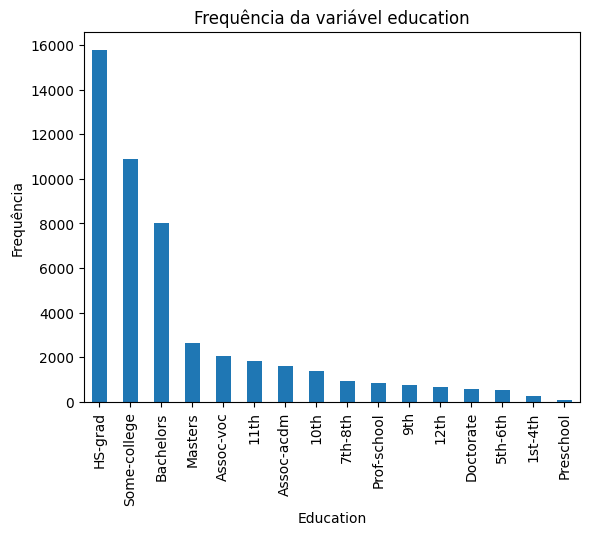

In [13]:
import matplotlib.pyplot as plt

df['education'].value_counts().plot(kind='bar')
plt.title('Frequência da variável education')
plt.xlabel('Education')
plt.ylabel('Frequência')
plt.show()

### <font color='cyan'> Q11: Escolha uma característica numérica do conjunto de dados. Escreva seu nome a seguir.</font>

hours-per-week

### <font color='cyan'> Q13: Crie e exiba um Histograma e/ou uma Estimativa de Densidade por Kernel (KDE) para a característica escolhida.</font>

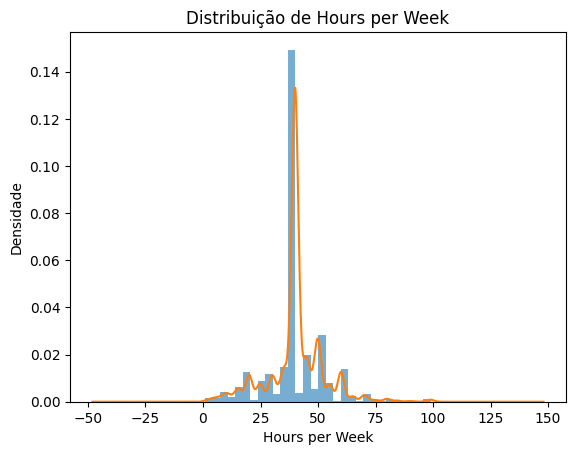

In [14]:
import matplotlib.pyplot as plt

df['hours-per-week'].plot(kind='hist', bins=30, density=True, alpha=0.6)
df['hours-per-week'].plot(kind='kde')

plt.title('Distribuição de Hours per Week')
plt.xlabel('Hours per Week')
plt.ylabel('Densidade')
plt.show()

## <font color='green'>**2.4 Análise Bivariada**</font>

### <font color='cyan'> Q14: Escolha duas características do conjuntos de dados. Escreva seus nome a seguir.</font>

education-num e hours-per-week

### <font color='cyan'> Q15: De acordo com os tipos das características escolhidas, produza pelo menos uma visualização de análise bivariada.</font>

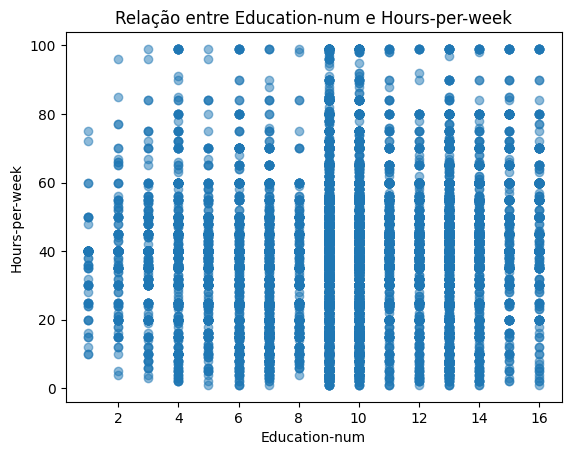

In [15]:
import matplotlib.pyplot as plt

plt.scatter(df['education-num'], df['hours-per-week'], alpha=0.5)

plt.title('Relação entre Education-num e Hours-per-week')
plt.xlabel('Education-num')
plt.ylabel('Hours-per-week')

plt.show()

## <font color='green'>**2.5 Identificação de Problemas nos Dados**</font>

### <font color='cyan'> Q16: Inspecione o conjuntos de dados para verificar se há:</font>
- #### <font color='cyan'> Dados Ausentes;</font>
- #### <font color='cyan'> Valores Atípicos (via IQR);</font>
- #### <font color='cyan'> Valores Duplicados;</font>
### <font color='cyan'> Reporte sua(s) descoberta(s) a seguir.</font>

In [16]:
# Verificando Dados Ausentes
df.isnull().sum()

age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
income              0
dtype: int64

In [17]:
# Verificando valores duplicados
df.duplicated().sum()

np.int64(29)

In [18]:
# Detectando Valores Atípicos (via IQR);

Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[(df['age'] < limite_inferior) | (df['age'] > limite_superior)]

print("Quantidade de outliers:", outliers.shape[0])

Quantidade de outliers: 216


* Existem 963 valores ausentes em workclass, 966 em occupation e 274 em native-country.
* O conjunto de dados possui 29 registros duplicados.
* Foram identificados 216 valores atípicos na variável age utilizando o método IQR.

### <font color='cyan'> Q17: Caso um problema tenha sido encontrado, proponha uma solução para ele.</font>
### <font color='cyan'> Exiba o conjunto de dados antes e depois da solução, enfatizando as mudanças.</font>

In [19]:
print("conjunto de dados antes da limpeza:", df.shape)
df.head()

# Remover valores ausentes
df_clean = df.dropna()

# Remover duplicados
df_clean = df_clean.drop_duplicates()

print("conjunto de dados depois da limpeza:", df_clean.shape)
df_clean.head()

conjunto de dados antes da limpeza: (48842, 15)
conjunto de dados depois da limpeza: (47592, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## <font color='green'>**2.6 Correlação Simples**</font>

### <font color='cyan'> Q18: Escolha duas características numéricas do conjuntos de dados. Escreva seus nomes a seguir.</font>

capital-gain e capital-loss

### <font color='cyan'> Q19: Calcule e exiba o Coeficiente de Correlação de Pearson ($r$) entre elas.</font>

In [20]:
# Calculando a correlação de Pearson
correlacao = df['capital-gain'].corr(df['capital-loss'])

print("Coeficiente de Correlação de Pearson (r):", correlacao)

Coeficiente de Correlação de Pearson (r): -0.031440770647463485


### <font color='cyan'> Q20: Interprete o coeficiente de correlação, em termos de sinal e magnitude.</font>

O coeficiente de correlação de Pearson obtido foi r = -0.03144077064746342. O sinal negativo esta indicando uma relação inversa entre as variáveis ***capital-gain*** e ***capital-loss***. No entanto, como o valor está muito próximo de zero, a magnitude da correlação é muito fraca, indicando que praticamente não existe relação linear significativa entre essas duas características no conjunto de dados.